# Convergence Recovery Notebook

This notebook identifies networks that did not meet the convergence criteria and resumes training from their checkpoints.

The workflow is:
1. Recompute convergence metrics from checkpoint histories.
2. Select non-converged networks.
3. Continue training from each checkpoint with optional early-stop-on-plateau.
4. Compare before vs after convergence metrics and save recovered checkpoints.

In [1]:
from __future__ import annotations

import importlib
import random
import sys
import time
from contextlib import contextmanager
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path(r"C:/Users/Priya/Desktop/research project (SNN Info Theory)")
PROJECT_FILES = PROJECT_ROOT / "Project Files"
CHECKPOINT_DIR = PROJECT_FILES / "Checkpoints"
PARITY_CKPT_DIR = CHECKPOINT_DIR / "Parity"
RECOVERY_DIR = CHECKPOINT_DIR / "Recovery"

WIMFO_ROOT = PROJECT_ROOT / "wimfo"
PAPER_ROOT = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

data_gen_mod = importlib.import_module("data_gen")
open_file = data_gen_mod.open_file
sparse_data_generator = data_gen_mod.sparse_data_generator

RSNN = importlib.import_module("model").RSNN
repo_loss = importlib.import_module("reg_loss").loss
clipper = importlib.import_module("clipper").ZeroOneClipper()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SHD_TRAIN = PROJECT_ROOT / "data" / "shd" / "shd_train.h5"
SHD_TEST = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"

print(f"Device: {DEVICE}")
print(f"Project files folder exists: {PROJECT_FILES.exists()}")
print(f"SHD train exists: {SHD_TRAIN.exists()}")
print(f"SHD test exists: {SHD_TEST.exists()}")

Device: cuda
Project files folder exists: True
SHD train exists: True
SHD test exists: True


Convergence status table
--------------------------------------------------------------------------------------------------------------------------------------------
      short      task                 arch  best_epoch  best_test_acc  final_test_acc  best_minus_final  tail_delta_last5  tail_std_last5  converged                status
      2C-LH   2-class            Local-Hom          15         0.8291          0.8149            0.0141           -0.0119          0.0151      False                 mixed
      2C-LN   2-class    FittedHet-LogNorm          17         0.8821          0.8723            0.0097           -0.0044          0.0089       True plateaued / converged
      2C-LU   2-class FittedHet-LogUniform          23         0.8308          0.8304            0.0004            0.0110          0.0117      False          near plateau
      4C-LH   4-class            Local-Hom          23         0.5424          0.5137            0.0287           -0.0071          0.0099       True p

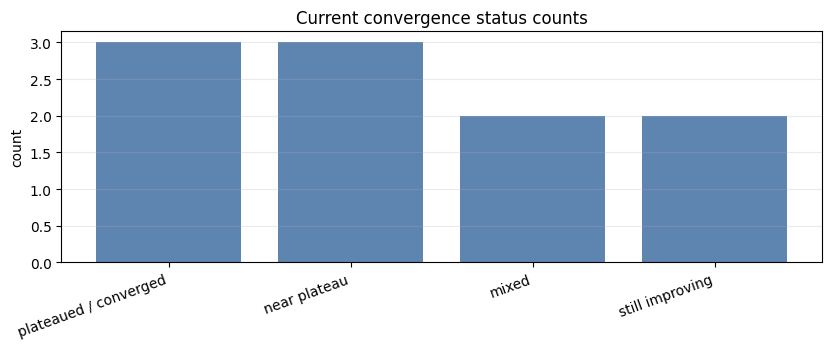

In [2]:
NETWORK_CATALOG = [
    {"network_id": "all_local_hom", "short": "ALL-LH", "task": "all-class", "arch": "Local-Hom", "checkpoint": CHECKPOINT_DIR / "local_hom_checkpoint.pt"},
    {"network_id": "all_fittedhet_ln", "short": "ALL-LN", "task": "all-class", "arch": "FittedHet-LogNorm", "checkpoint": CHECKPOINT_DIR / "fittedhet_lognorm_mem_gamma_syn_checkpoint.pt"},
    {"network_id": "all_fittedhet_lu", "short": "ALL-LU", "task": "all-class", "arch": "FittedHet-LogUniform", "checkpoint": CHECKPOINT_DIR / "fittedhet_loguniform_mem_gamma_syn_checkpoint.pt"},
    {"network_id": "all_repo_het", "short": "ALL-RepoHet", "task": "all-class", "arch": "Repo-Learned-Het", "checkpoint": CHECKPOINT_DIR / "network_A_checkpoint.pt"},
    {"network_id": "2class_local_hom", "short": "2C-LH", "task": "2-class", "arch": "Local-Hom", "checkpoint": PARITY_CKPT_DIR / "2class_local_hom.pt"},
    {"network_id": "2class_fittedhet_ln", "short": "2C-LN", "task": "2-class", "arch": "FittedHet-LogNorm", "checkpoint": PARITY_CKPT_DIR / "2class_fittedhet_lognorm.pt"},
    {"network_id": "2class_fittedhet_lu", "short": "2C-LU", "task": "2-class", "arch": "FittedHet-LogUniform", "checkpoint": PARITY_CKPT_DIR / "2class_fittedhet_loguniform.pt"},
    {"network_id": "4class_local_hom", "short": "4C-LH", "task": "4-class", "arch": "Local-Hom", "checkpoint": PARITY_CKPT_DIR / "4class_local_hom.pt"},
    {"network_id": "4class_fittedhet_ln", "short": "4C-LN", "task": "4-class", "arch": "FittedHet-LogNorm", "checkpoint": PARITY_CKPT_DIR / "4class_fittedhet_lognorm.pt"},
    {"network_id": "4class_fittedhet_lu", "short": "4C-LU", "task": "4-class", "arch": "FittedHet-LogUniform", "checkpoint": PARITY_CKPT_DIR / "4class_fittedhet_loguniform.pt"},
]

def score_history(train_acc, test_acc):
    train_arr = np.asarray(train_acc, dtype=float)
    test_arr = np.asarray(test_acc, dtype=float)
    finite_idx = np.where(np.isfinite(test_arr))[0]
    if finite_idx.size == 0:
        return {
            "epochs": np.nan,
            "best_epoch": np.nan,
            "best_test_acc": np.nan,
            "final_test_acc": np.nan,
            "best_minus_final": np.nan,
            "tail_delta_last5": np.nan,
            "tail_std_last5": np.nan,
            "final_train_test_gap": np.nan,
            "converged": False,
            "status": "missing history",
        }

    n_epochs = int(test_arr.size)
    best_idx = int(finite_idx[np.argmax(test_arr[finite_idx])])
    best_epoch = best_idx + 1
    best_test = float(test_arr[best_idx])
    final_test = float(test_arr[-1])
    best_minus_final = float(best_test - final_test)

    tail_len = int(min(5, n_epochs))
    tail = test_arr[-tail_len:]
    tail_delta = float(tail[-1] - tail[0]) if tail_len > 1 else 0.0
    tail_std = float(np.nanstd(tail))

    final_train = float(train_arr[-1]) if train_arr.size else np.nan
    train_test_gap = float(final_train - final_test) if np.isfinite(final_train) else np.nan

    reached_late_peak = best_epoch >= max(n_epochs - 2, 1)
    flat_tail = (abs(tail_delta) <= 0.010) and (tail_std <= 0.015)
    small_peak_drop = best_minus_final <= 0.015
    converged = bool(flat_tail and (small_peak_drop or reached_late_peak))

    if best_epoch == n_epochs and tail_delta > 0.010:
        status = "still improving"
    elif best_minus_final > 0.025 and best_epoch <= n_epochs - 4:
        status = "peaked then regressed"
    elif converged:
        status = "plateaued / converged"
    elif reached_late_peak and abs(tail_delta) <= 0.020:
        status = "near plateau"
    else:
        status = "mixed"

    return {
        "epochs": n_epochs,
        "best_epoch": best_epoch,
        "best_test_acc": best_test,
        "final_test_acc": final_test,
        "best_minus_final": best_minus_final,
        "tail_delta_last5": tail_delta,
        "tail_std_last5": tail_std,
        "final_train_test_gap": train_test_gap,
        "converged": converged,
        "status": status,
    }

rows = []
for entry in NETWORK_CATALOG:
    ckpt_path = Path(entry["checkpoint"])
    row = {
        "network_id": entry["network_id"],
        "short": entry["short"],
        "task": entry["task"],
        "arch": entry["arch"],
        "checkpoint": str(ckpt_path),
    }

    if not ckpt_path.exists():
        row.update({
            "epochs": np.nan,
            "best_epoch": np.nan,
            "best_test_acc": np.nan,
            "final_test_acc": np.nan,
            "best_minus_final": np.nan,
            "tail_delta_last5": np.nan,
            "tail_std_last5": np.nan,
            "final_train_test_gap": np.nan,
            "converged": False,
            "status": "missing checkpoint",
        })
    else:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        history = ckpt.get("history", {})
        score = score_history(history.get("train_acc", []), history.get("test_acc", []))
        row.update(score)

    rows.append(row)

convergence_df = pd.DataFrame(rows).sort_values(["task", "short"]).reset_index(drop=True)
needs_recovery_df = convergence_df[(~convergence_df["converged"]) & (convergence_df["status"] != "missing checkpoint")].copy()

print("Convergence status table")
print("-" * 140)
print(convergence_df[["short", "task", "arch", "best_epoch", "best_test_acc", "final_test_acc", "best_minus_final", "tail_delta_last5", "tail_std_last5", "converged", "status"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nRecovery targets (non-converged)")
print("-" * 100)
if needs_recovery_df.empty:
    print("No non-converged checkpoints found.")
else:
    print(needs_recovery_df[["short", "task", "arch", "status", "best_minus_final", "tail_delta_last5"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

status_counts = convergence_df["status"].value_counts().rename_axis("status").reset_index(name="count")
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(status_counts["status"], status_counts["count"], color="#4c78a8", alpha=0.9)
ax.set_title("Current convergence status counts")
ax.set_ylabel("count")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_2class_task():
    return {
        "nb_outputs": 2,
        "task_label_map": {i: i % 2 for i in range(20)},
        "class_list": list(range(20)),
    }

def make_4class_task():
    label_map = {}
    for i in range(20):
        is_german = int(i >= 10)
        is_odd = int(i % 2 == 1)
        label_map[i] = is_german * 2 + is_odd
    return {
        "nb_outputs": 4,
        "task_label_map": label_map,
        "class_list": list(range(20)),
    }

TASK_OVERRIDES = {
    "all-class": {"nb_outputs": 20, "task_label_map": None, "class_list": list(range(20))},
    "2-class": make_2class_task(),
    "4-class": make_4class_task(),
}

class SHDCache:
    def __init__(self, path):
        raw_u, raw_t, raw_l = open_file(str(path))
        self.units = list(raw_u[:])
        self.times = list(raw_t[:])
        self.labels = np.array(raw_l[:])
        raw_u._v_file.close()
        print(f"  SHDCache: {len(self.labels)} samples loaded from {Path(str(path)).name}")

def _is_cache(obj):
    return hasattr(obj, "units") and hasattr(obj, "times") and hasattr(obj, "labels")

@contextmanager
def shd_open(path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()

@contextmanager
def shd_open_cached(cache):
    yield cache.units, cache.times, cache.labels

def count_epoch_samples(sample_count, batch_size, drop_last, batch_limit=None):
    if drop_last:
        n_batches = sample_count // batch_size
    else:
        n_batches = -(-sample_count // batch_size)
    if batch_limit is not None:
        n_batches = min(n_batches, int(batch_limit))
    if drop_last:
        return n_batches * batch_size
    if batch_limit is None:
        return sample_count
    return min(sample_count, n_batches * batch_size)

def fast_sparse_data_generator(units, times, labels, prms, shuffle=True, epoch=0, drop_last=True, batch_limit=None):
    rate = prms.get("rate", 0.0)
    p_del = prms.get("p_del", 0.0)
    if rate != 0.0 or p_del != 0.0:
        yield from sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last)
        return

    seed = int(prms.get("seed", 1000)) + int(epoch)
    batch_size = int(prms["batch_size"])
    nb_steps = int(prms["nb_steps"])
    nb_units = int(prms["nb_inputs"])
    inv_dt = 1.0 / float(prms["time_step"])
    class_list = list(prms["class_list"])
    task_label_map = prms.get("task_label_map", None)

    label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples = len(sample_index)
    n_batches = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)
    if batch_limit is not None:
        n_batches = min(n_batches, int(batch_limit))

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(sample_index)

    for counter in range(n_batches):
        start = batch_size * counter
        stop = min(num_samples, batch_size * (counter + 1))
        batch_index = sample_index[start:stop]
        actual_bs = len(batch_index)

        t_arrays = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays = [units[idx] for idx in batch_index]
        lengths = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            i = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            v = torch.ones(all_ts.size, dtype=torch.float32)
            x_batch = torch.sparse_coo_tensor(i, v, torch.Size([actual_bs, nb_steps, nb_units])).to_dense()
        else:
            x_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        x_batch.clamp_(max=1.0)
        if task_label_map is not None:
            y_batch = torch.tensor([task_label_map[int(a)] for a in label_arr[batch_index]], dtype=torch.long)
        else:
            y_batch = torch.tensor([class_list.index(int(a)) for a in label_arr[batch_index]], dtype=torch.long)

        yield x_batch, y_batch

def shd_generator(units, times, labels, prms, shuffle, epoch, drop_last, batch_limit=None):
    yield from fast_sparse_data_generator(units, times, labels, prms, shuffle=shuffle, epoch=epoch, drop_last=drop_last, batch_limit=batch_limit)

def forward_logits(model, x):
    layer_recs = model(0, 0, x)
    output_layer = layer_recs[-1]
    logits, _ = torch.max(output_layer[1], dim=1)
    return logits, layer_recs

def make_optimizer(model, prms):
    weight_params, ab_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "alpha" in name or "beta" in name:
            ab_params.append(param)
        else:
            weight_params.append(param)

    param_groups = [{
        "params": weight_params,
        "lr": float(prms["lr"]),
        "weight_decay": float(prms.get("weight_decay", 0.0)),
    }]
    if ab_params:
        param_groups.append({"params": ab_params, "lr": float(prms.get("lr_ab", prms["lr"]))})

    betas = tuple(prms.get("betas", (0.9, 0.999)))
    return torch.optim.Adam(param_groups, betas=betas)

@torch.no_grad()
def evaluate_batches(model, prms, units, times, labels, num_samples=None, batch_limit=None, use_amp=True):
    if num_samples is None:
        total = int(np.isin(labels[:], prms["class_list"]).sum())
        num_samples = count_epoch_samples(total, int(prms["batch_size"]), drop_last=False, batch_limit=batch_limit)

    use_amp = bool(use_amp and DEVICE.type == "cuda")
    model.eval()
    loss_acc, correct = 0.0, 0
    for x, y in shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False, batch_limit=batch_limit):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
            logits, layer_recs = forward_logits(model, x)
            loss_acc += repo_loss(logits, layer_recs, y, num_samples, prms).item()
        correct += (logits.argmax(1) == y).sum().item()

    return {"loss": loss_acc, "acc": correct / max(num_samples, 1), "n": num_samples}

def continue_training(model, prms, train_data, test_data, extra_epochs=10, patience=4, min_delta=0.002, batch_limit=None, use_amp=True):
    use_amp = bool(use_amp and DEVICE.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    optimizer = make_optimizer(model, prms)

    history_ext = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_test = -np.inf
    stale_epochs = 0
    stop_reason = "max extra epochs reached"

    tr_ctx = shd_open_cached if _is_cache(train_data) else shd_open
    te_ctx = shd_open_cached if _is_cache(test_data) else shd_open

    with tr_ctx(train_data) as (u_tr, t_tr, l_tr), te_ctx(test_data) as (u_te, t_te, l_te):
        total_tr = int(np.isin(l_tr[:], prms["class_list"]).sum())
        total_te = int(np.isin(l_te[:], prms["class_list"]).sum())
        eff_tr = count_epoch_samples(total_tr, int(prms["batch_size"]), drop_last=bool(prms.get("drop_last", True)), batch_limit=batch_limit)
        eff_te = count_epoch_samples(total_te, int(prms["batch_size"]), drop_last=False, batch_limit=batch_limit)

        if int(prms.get("clip", 1)):
            model.apply(clipper)

        for extra_epoch in range(1, int(extra_epochs) + 1):
            t0 = time.perf_counter()
            model.train()
            ep_loss, ep_correct = 0.0, 0

            for x, y in shd_generator(u_tr, t_tr, l_tr, prms, shuffle=True, epoch=extra_epoch, drop_last=bool(prms.get("drop_last", True)), batch_limit=batch_limit):
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=use_amp):
                    logits, layer_recs = forward_logits(model, x)
                    loss_val = repo_loss(logits, layer_recs, y, eff_tr, prms)

                scaler.scale(loss_val).backward()
                scaler.step(optimizer)
                scaler.update()

                if int(prms.get("clip", 1)):
                    model.apply(clipper)

                ep_loss += float(loss_val.item())
                ep_correct += int((logits.argmax(1) == y).sum().item())

            test_m = evaluate_batches(model, prms, u_te, t_te, l_te, num_samples=eff_te, batch_limit=batch_limit, use_amp=use_amp)
            train_acc = ep_correct / max(eff_tr, 1)
            test_acc = float(test_m["acc"])

            history_ext["train_loss"].append(ep_loss)
            history_ext["train_acc"].append(train_acc)
            history_ext["test_loss"].append(float(test_m["loss"]))
            history_ext["test_acc"].append(test_acc)

            if test_acc > best_test + float(min_delta):
                best_test = test_acc
                stale_epochs = 0
            else:
                stale_epochs += 1

            elapsed = time.perf_counter() - t0
            print(f"  extra_epoch={extra_epoch:03d} train_acc={train_acc:.3f} test_acc={test_acc:.3f} stale={stale_epochs} ({elapsed/60:.1f} min)")

            if stale_epochs >= int(patience):
                stop_reason = f"early stop: no +{float(min_delta):.4f} test gain for {int(patience)} epochs"
                break

    ran_epochs = len(history_ext["test_acc"])
    return history_ext, stop_reason, ran_epochs

def merge_histories(history_before, history_ext):
    merged = {}
    for key in ["train_loss", "train_acc", "test_loss", "test_acc"]:
        merged[key] = list(history_before.get(key, [])) + list(history_ext.get(key, []))
    return merged

print("Training helpers ready.")

Training helpers ready.


In [ ]:
RUN_RECOVERY = True
EXTRA_EPOCHS = 8
PATIENCE = 4
MIN_DELTA = 0.002
BATCH_LIMIT = None
MAX_NETWORKS_TO_RUN = None
USE_AMP = True
SAVE_RECOVERY_CHECKPOINTS = True

print("Recovery config")
print("-" * 70)
print(f"RUN_RECOVERY={RUN_RECOVERY}")
print(f"EXTRA_EPOCHS={EXTRA_EPOCHS} | PATIENCE={PATIENCE} | MIN_DELTA={MIN_DELTA}")
print(f"BATCH_LIMIT={BATCH_LIMIT} | MAX_NETWORKS_TO_RUN={MAX_NETWORKS_TO_RUN}")

print("\nPre-loading SHD data into RAM...")
SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
SHD_TEST_CACHE = SHDCache(SHD_TEST)

targets = needs_recovery_df.sort_values(["task", "best_minus_final"], ascending=[True, False]).reset_index(drop=True)
if MAX_NETWORKS_TO_RUN is not None:
    targets = targets.head(int(MAX_NETWORKS_TO_RUN))

print("\nSelected recovery targets")
print("-" * 70)
if targets.empty:
    print("No targets found.")
else:
    print(targets[["short", "task", "arch", "status", "best_minus_final"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

catalog_by_short = {entry["short"]: entry for entry in NETWORK_CATALOG}
recovery_rows = []

for _, target in targets.iterrows():
    short = target["short"]
    entry = catalog_by_short[short]
    ckpt_path = Path(entry["checkpoint"])

    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    history_before = checkpoint.get("history", {})
    before_metrics = score_history(history_before.get("train_acc", []), history_before.get("test_acc", []))

    saved_prms = dict(checkpoint.get("prms", {}))
    prms = dict(saved_prms)
    prms.update(TASK_OVERRIDES[target["task"]])
    prms["device"] = DEVICE
    prms["dtype"] = torch.float
    prms["cuda"] = DEVICE.type == "cuda"
    prms["drop_last"] = bool(prms.get("drop_last", True))
    prms["batch_size"] = int(prms.get("batch_size", 256))
    prms["nb_steps"] = int(prms.get("nb_steps", 1000))
    prms["nb_inputs"] = int(prms.get("nb_inputs", 700))
    prms["time_step"] = float(prms.get("time_step", 1e-3))
    prms["lr"] = float(prms.get("lr", 4e-3))
    prms["lr_ab"] = float(prms.get("lr_ab", prms["lr"]))
    prms["weight_decay"] = float(prms.get("weight_decay", 0.0))
    prms["betas"] = tuple(prms.get("betas", (0.9, 0.999)))

    if "seed" not in prms:
        prms["seed"] = 1000
    set_seed(int(prms["seed"]))

    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    ext_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    stop_reason = "not run"
    ran_epochs = 0

    print(f"\n[{short}] {entry['task']} | {entry['arch']}")
    print(f"  Before: final_test={before_metrics['final_test_acc']:.4f}, status={before_metrics['status']}")

    if RUN_RECOVERY:
        ext_history, stop_reason, ran_epochs = continue_training(
            model,
            prms,
            SHD_TRAIN_CACHE,
            SHD_TEST_CACHE,
            extra_epochs=EXTRA_EPOCHS,
            patience=PATIENCE,
            min_delta=MIN_DELTA,
            batch_limit=BATCH_LIMIT,
            use_amp=USE_AMP,
        )

    history_after = merge_histories(history_before, ext_history)
    after_metrics = score_history(history_after.get("train_acc", []), history_after.get("test_acc", []))

    saved_path = ""
    if RUN_RECOVERY and SAVE_RECOVERY_CHECKPOINTS:
        RECOVERY_DIR.mkdir(parents=True, exist_ok=True)
        out_path = RECOVERY_DIR / f"{ckpt_path.stem}_recovery.pt"
        payload = {
            "model_state_dict": model.state_dict(),
            "history": history_after,
            "elapsed_s": float(checkpoint.get("elapsed_s", 0.0)),
            "prms": {k: v for k, v in prms.items() if not isinstance(v, (torch.device, torch.dtype))},
            "source_checkpoint": str(ckpt_path),
            "recovery_config": {
                "extra_epochs": int(EXTRA_EPOCHS),
                "patience": int(PATIENCE),
                "min_delta": float(MIN_DELTA),
                "batch_limit": None if BATCH_LIMIT is None else int(BATCH_LIMIT),
                "ran_epochs": int(ran_epochs),
            },
            "stop_reason": stop_reason,
        }
        torch.save(payload, out_path)
        saved_path = str(out_path)

    print(f"  After:  final_test={after_metrics['final_test_acc']:.4f}, status={after_metrics['status']}")
    if RUN_RECOVERY:
        print(f"  Extra epochs ran: {ran_epochs} | stop: {stop_reason}")

    recovery_rows.append({
        "short": short,
        "task": entry["task"],
        "arch": entry["arch"],
        "before_status": before_metrics["status"],
        "after_status": after_metrics["status"],
        "before_converged": bool(before_metrics["converged"]),
        "after_converged": bool(after_metrics["converged"]),
        "before_final_test": before_metrics["final_test_acc"],
        "after_final_test": after_metrics["final_test_acc"],
        "before_best_minus_final": before_metrics["best_minus_final"],
        "after_best_minus_final": after_metrics["best_minus_final"],
        "extra_epochs_ran": int(ran_epochs),
        "stop_reason": stop_reason,
        "saved_checkpoint": saved_path,
    })

recovery_df = pd.DataFrame(recovery_rows)

print("\nRecovery summary")
print("-" * 140)
if recovery_df.empty:
    print("No recovery rows produced.")
else:
    print(recovery_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

if not recovery_df.empty:
    plot_df = recovery_df.copy()
    x = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    axes[0].bar(x - 0.18, plot_df["before_final_test"], width=0.36, label="before", color="#9ecae1")
    axes[0].bar(x + 0.18, plot_df["after_final_test"], width=0.36, label="after", color="#2b8cbe")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(plot_df["short"], rotation=25, ha="right")
    axes[0].set_title("Final test accuracy before vs after recovery")
    axes[0].set_ylabel("final test accuracy")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].bar(x - 0.18, plot_df["before_best_minus_final"], width=0.36, label="before", color="#fdd0a2")
    axes[1].bar(x + 0.18, plot_df["after_best_minus_final"], width=0.36, label="after", color="#e6550d")
    axes[1].axhline(0.015, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(plot_df["short"], rotation=25, ha="right")
    axes[1].set_title("Peak-to-final drop before vs after")
    axes[1].set_ylabel("best test - final test")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.show()

## Quick Pilot Recovery Run

Use this section to run a fast proof-of-loop recovery attempt before launching longer full recovery runs.

Defaults below run one non-converged network for one extra epoch with a capped batch count.

In [4]:
PILOT_EXTRA_EPOCHS = 1
PILOT_PATIENCE = 1
PILOT_MIN_DELTA = 0.001
PILOT_BATCH_LIMIT = 12
PILOT_MAX_NETWORKS = 1
PILOT_SAVE_CHECKPOINTS = True

print("Pilot recovery config")
print("-" * 70)
print(f"extra_epochs={PILOT_EXTRA_EPOCHS} | patience={PILOT_PATIENCE} | min_delta={PILOT_MIN_DELTA}")
print(f"batch_limit={PILOT_BATCH_LIMIT} | max_networks={PILOT_MAX_NETWORKS}")

if "SHD_TRAIN_CACHE" not in globals() or "SHD_TEST_CACHE" not in globals():
    print("Loading SHD caches for pilot run...")
    SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
    SHD_TEST_CACHE = SHDCache(SHD_TEST)

pilot_targets = needs_recovery_df.copy().sort_values(["task", "best_minus_final"], ascending=[True, False]).head(PILOT_MAX_NETWORKS)
print("\nPilot targets")
print("-" * 70)
if pilot_targets.empty:
    print("No non-converged targets available.")
else:
    print(pilot_targets[["short", "task", "arch", "status", "best_minus_final"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

catalog_by_short = {entry["short"]: entry for entry in NETWORK_CATALOG}
pilot_rows = []

for _, target in pilot_targets.iterrows():
    short = target["short"]
    entry = catalog_by_short[short]
    ckpt_path = Path(entry["checkpoint"])
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    history_before = checkpoint.get("history", {})
    before_metrics = score_history(history_before.get("train_acc", []), history_before.get("test_acc", []))

    saved_prms = dict(checkpoint.get("prms", {}))
    prms = dict(saved_prms)
    prms.update(TASK_OVERRIDES[target["task"]])
    prms["device"] = DEVICE
    prms["dtype"] = torch.float
    prms["cuda"] = DEVICE.type == "cuda"
    prms["drop_last"] = bool(prms.get("drop_last", True))
    prms["batch_size"] = int(prms.get("batch_size", 256))
    prms["nb_steps"] = int(prms.get("nb_steps", 1000))
    prms["nb_inputs"] = int(prms.get("nb_inputs", 700))
    prms["time_step"] = float(prms.get("time_step", 1e-3))
    prms["lr"] = float(prms.get("lr", 4e-3))
    prms["lr_ab"] = float(prms.get("lr_ab", prms["lr"]))
    prms["weight_decay"] = float(prms.get("weight_decay", 0.0))
    prms["betas"] = tuple(prms.get("betas", (0.9, 0.999)))
    if "seed" not in prms:
        prms["seed"] = 1000

    set_seed(int(prms["seed"]))
    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    print(f"\n[{short}] before final_test={before_metrics['final_test_acc']:.4f}, status={before_metrics['status']}")
    ext_history, stop_reason, ran_epochs = continue_training(
        model,
        prms,
        SHD_TRAIN_CACHE,
        SHD_TEST_CACHE,
        extra_epochs=PILOT_EXTRA_EPOCHS,
        patience=PILOT_PATIENCE,
        min_delta=PILOT_MIN_DELTA,
        batch_limit=PILOT_BATCH_LIMIT,
        use_amp=True,
    )

    history_after = merge_histories(history_before, ext_history)
    after_metrics = score_history(history_after.get("train_acc", []), history_after.get("test_acc", []))
    print(f"[{short}] after  final_test={after_metrics['final_test_acc']:.4f}, status={after_metrics['status']}")

    saved_path = ""
    if PILOT_SAVE_CHECKPOINTS:
        RECOVERY_DIR.mkdir(parents=True, exist_ok=True)
        out_path = RECOVERY_DIR / f"{ckpt_path.stem}_pilot_recovery.pt"
        payload = {
            "model_state_dict": model.state_dict(),
            "history": history_after,
            "elapsed_s": float(checkpoint.get("elapsed_s", 0.0)),
            "prms": {k: v for k, v in prms.items() if not isinstance(v, (torch.device, torch.dtype))},
            "source_checkpoint": str(ckpt_path),
            "pilot_config": {
                "extra_epochs": int(PILOT_EXTRA_EPOCHS),
                "patience": int(PILOT_PATIENCE),
                "min_delta": float(PILOT_MIN_DELTA),
                "batch_limit": int(PILOT_BATCH_LIMIT),
                "ran_epochs": int(ran_epochs),
            },
            "stop_reason": stop_reason,
        }
        torch.save(payload, out_path)
        saved_path = str(out_path)

    pilot_rows.append(
        {
            "short": short,
            "task": target["task"],
            "before_status": before_metrics["status"],
            "after_status": after_metrics["status"],
            "before_converged": bool(before_metrics["converged"]),
            "after_converged": bool(after_metrics["converged"]),
            "before_final_test": before_metrics["final_test_acc"],
            "after_final_test": after_metrics["final_test_acc"],
            "delta_final_test": after_metrics["final_test_acc"] - before_metrics["final_test_acc"],
            "extra_epochs_ran": int(ran_epochs),
            "stop_reason": stop_reason,
            "saved_checkpoint": saved_path,
        }
    )

pilot_df = pd.DataFrame(pilot_rows)
print("\nPilot recovery summary")
print("-" * 120)
if pilot_df.empty:
    print("No pilot results.")
else:
    print(pilot_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Pilot recovery config
----------------------------------------------------------------------
extra_epochs=1 | patience=1 | min_delta=0.001
batch_limit=12 | max_networks=1
Loading SHD caches for pilot run...
  SHDCache: 8156 samples loaded from shd_train.h5
  SHDCache: 2264 samples loaded from shd_test.h5

Pilot targets
----------------------------------------------------------------------
short    task      arch status  best_minus_final
2C-LH 2-class Local-Hom  mixed            0.0141

[2C-LH] before final_test=0.8149, status=mixed
  extra_epoch=001 train_acc=0.889 test_acc=0.761 stale=0 (1.2 min)
[2C-LH] after  final_test=0.7606, status=peaked then regressed

Pilot recovery summary
------------------------------------------------------------------------------------------------------------------------
short    task before_status          after_status  before_converged  after_converged  before_final_test  after_final_test  delta_final_test  extra_epochs_ran              stop_reason     

5-epoch recovery config
----------------------------------------------------------------------
RUN_RECOVERY_5EP=True
EXTRA_EPOCHS_5EP=5 | PATIENCE_5EP=4 | MIN_DELTA_5EP=0.002
BATCH_LIMIT_5EP=None

5-epoch targets
----------------------------------------------------------------------
 short      task                 arch          status  best_minus_final
 2C-LH   2-class            Local-Hom           mixed            0.0141
 2C-LU   2-class FittedHet-LogUniform    near plateau            0.0004
 4C-LN   4-class    FittedHet-LogNorm    near plateau            0.0194
 4C-LU   4-class FittedHet-LogUniform           mixed            0.0062
ALL-LN all-class    FittedHet-LogNorm    near plateau            0.0225
ALL-LH all-class            Local-Hom still improving            0.0000
ALL-LU all-class FittedHet-LogUniform still improving            0.0000

[2C-LH] 2-class | Local-Hom
  Before: final_test=0.8149, status=mixed
  extra_epoch=001 train_acc=0.902 test_acc=0.802 stale=0 (3.6 min)
  

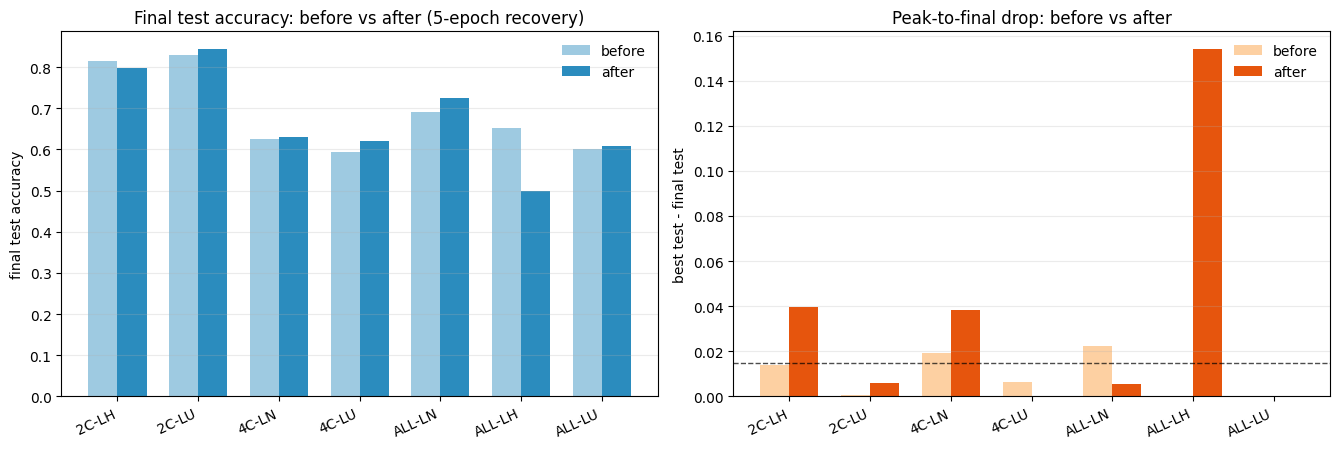

In [5]:
# Full recovery pass requested: ~5 extra epochs for each non-converged network
RUN_RECOVERY_5EP = True
EXTRA_EPOCHS_5EP = 5
PATIENCE_5EP = 4
MIN_DELTA_5EP = 0.002
BATCH_LIMIT_5EP = None
USE_AMP_5EP = True
SAVE_RECOVERY_5EP = True

print("5-epoch recovery config")
print("-" * 70)
print(f"RUN_RECOVERY_5EP={RUN_RECOVERY_5EP}")
print(f"EXTRA_EPOCHS_5EP={EXTRA_EPOCHS_5EP} | PATIENCE_5EP={PATIENCE_5EP} | MIN_DELTA_5EP={MIN_DELTA_5EP}")
print(f"BATCH_LIMIT_5EP={BATCH_LIMIT_5EP}")

if "SHD_TRAIN_CACHE" not in globals() or "SHD_TEST_CACHE" not in globals():
    print("Loading SHD caches...")
    SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
    SHD_TEST_CACHE = SHDCache(SHD_TEST)

targets_5ep = needs_recovery_df.sort_values(["task", "best_minus_final"], ascending=[True, False]).reset_index(drop=True)
print("\n5-epoch targets")
print("-" * 70)
if targets_5ep.empty:
    print("No non-converged targets found.")
else:
    print(targets_5ep[["short", "task", "arch", "status", "best_minus_final"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

catalog_by_short = {entry["short"]: entry for entry in NETWORK_CATALOG}
recovery_rows_5ep = []

for _, target in targets_5ep.iterrows():
    short = target["short"]
    entry = catalog_by_short[short]
    ckpt_path = Path(entry["checkpoint"])

    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    history_before = checkpoint.get("history", {})
    before_metrics = score_history(history_before.get("train_acc", []), history_before.get("test_acc", []))

    saved_prms = dict(checkpoint.get("prms", {}))
    prms = dict(saved_prms)
    prms.update(TASK_OVERRIDES[target["task"]])
    prms["device"] = DEVICE
    prms["dtype"] = torch.float
    prms["cuda"] = DEVICE.type == "cuda"
    prms["drop_last"] = bool(prms.get("drop_last", True))
    prms["batch_size"] = int(prms.get("batch_size", 256))
    prms["nb_steps"] = int(prms.get("nb_steps", 1000))
    prms["nb_inputs"] = int(prms.get("nb_inputs", 700))
    prms["time_step"] = float(prms.get("time_step", 1e-3))
    prms["lr"] = float(prms.get("lr", 4e-3))
    prms["lr_ab"] = float(prms.get("lr_ab", prms["lr"]))
    prms["weight_decay"] = float(prms.get("weight_decay", 0.0))
    prms["betas"] = tuple(prms.get("betas", (0.9, 0.999)))

    if "seed" not in prms:
        prms["seed"] = 1000
    set_seed(int(prms["seed"]))

    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    ext_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    stop_reason = "not run"
    ran_epochs = 0

    print(f"\n[{short}] {entry['task']} | {entry['arch']}")
    print(f"  Before: final_test={before_metrics['final_test_acc']:.4f}, status={before_metrics['status']}")

    if RUN_RECOVERY_5EP:
        ext_history, stop_reason, ran_epochs = continue_training(
            model,
            prms,
            SHD_TRAIN_CACHE,
            SHD_TEST_CACHE,
            extra_epochs=EXTRA_EPOCHS_5EP,
            patience=PATIENCE_5EP,
            min_delta=MIN_DELTA_5EP,
            batch_limit=BATCH_LIMIT_5EP,
            use_amp=USE_AMP_5EP,
        )

    history_after = merge_histories(history_before, ext_history)
    after_metrics = score_history(history_after.get("train_acc", []), history_after.get("test_acc", []))

    saved_path = ""
    if RUN_RECOVERY_5EP and SAVE_RECOVERY_5EP:
        RECOVERY_DIR.mkdir(parents=True, exist_ok=True)
        out_path = RECOVERY_DIR / f"{ckpt_path.stem}_recovery_5ep.pt"
        payload = {
            "model_state_dict": model.state_dict(),
            "history": history_after,
            "elapsed_s": float(checkpoint.get("elapsed_s", 0.0)),
            "prms": {k: v for k, v in prms.items() if not isinstance(v, (torch.device, torch.dtype))},
            "source_checkpoint": str(ckpt_path),
            "recovery_config": {
                "extra_epochs": int(EXTRA_EPOCHS_5EP),
                "patience": int(PATIENCE_5EP),
                "min_delta": float(MIN_DELTA_5EP),
                "batch_limit": None if BATCH_LIMIT_5EP is None else int(BATCH_LIMIT_5EP),
                "ran_epochs": int(ran_epochs),
            },
            "stop_reason": stop_reason,
        }
        torch.save(payload, out_path)
        saved_path = str(out_path)

    print(f"  After:  final_test={after_metrics['final_test_acc']:.4f}, status={after_metrics['status']}")
    if RUN_RECOVERY_5EP:
        print(f"  Extra epochs ran: {ran_epochs} | stop: {stop_reason}")

    recovery_rows_5ep.append(
        {
            "short": short,
            "task": entry["task"],
            "arch": entry["arch"],
            "before_status": before_metrics["status"],
            "after_status": after_metrics["status"],
            "before_converged": bool(before_metrics["converged"]),
            "after_converged": bool(after_metrics["converged"]),
            "before_final_test": before_metrics["final_test_acc"],
            "after_final_test": after_metrics["final_test_acc"],
            "delta_final_test": after_metrics["final_test_acc"] - before_metrics["final_test_acc"],
            "before_best_minus_final": before_metrics["best_minus_final"],
            "after_best_minus_final": after_metrics["best_minus_final"],
            "delta_best_minus_final": after_metrics["best_minus_final"] - before_metrics["best_minus_final"],
            "extra_epochs_ran": int(ran_epochs),
            "stop_reason": stop_reason,
            "saved_checkpoint": saved_path,
        }
    )

recovery_df_5ep = pd.DataFrame(recovery_rows_5ep)

print("\n5-epoch recovery summary")
print("-" * 160)
if recovery_df_5ep.empty:
    print("No recovery rows produced.")
else:
    print(recovery_df_5ep.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

if not recovery_df_5ep.empty:
    improved_conv = int((~recovery_df_5ep["before_converged"] & recovery_df_5ep["after_converged"]).sum())
    worsened_conv = int((recovery_df_5ep["before_converged"] & ~recovery_df_5ep["after_converged"]).sum())
    mean_delta_acc = float(recovery_df_5ep["delta_final_test"].mean())

    print("\nAggregate improvement stats")
    print("-" * 60)
    print(f"newly converged networks: {improved_conv}")
    print(f"worsened convergence flag: {worsened_conv}")
    print(f"mean delta final test acc: {mean_delta_acc:.4f}")

    x = np.arange(len(recovery_df_5ep))
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

    axes[0].bar(x - 0.18, recovery_df_5ep["before_final_test"], width=0.36, label="before", color="#9ecae1")
    axes[0].bar(x + 0.18, recovery_df_5ep["after_final_test"], width=0.36, label="after", color="#2b8cbe")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(recovery_df_5ep["short"], rotation=25, ha="right")
    axes[0].set_title("Final test accuracy: before vs after (5-epoch recovery)")
    axes[0].set_ylabel("final test accuracy")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].bar(x - 0.18, recovery_df_5ep["before_best_minus_final"], width=0.36, label="before", color="#fdd0a2")
    axes[1].bar(x + 0.18, recovery_df_5ep["after_best_minus_final"], width=0.36, label="after", color="#e6550d")
    axes[1].axhline(0.015, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(recovery_df_5ep["short"], rotation=25, ha="right")
    axes[1].set_title("Peak-to-final drop: before vs after")
    axes[1].set_ylabel("best test - final test")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.show()

In [6]:
if "recovery_df_5ep" not in globals() or recovery_df_5ep.empty:
    print("recovery_df_5ep is missing or empty. Re-run the 5-epoch recovery cell first.")
else:
    view_cols = [
        "short",
        "task",
        "before_status",
        "after_status",
        "before_converged",
        "after_converged",
        "before_final_test",
        "after_final_test",
        "delta_final_test",
        "before_best_minus_final",
        "after_best_minus_final",
        "delta_best_minus_final",
        "extra_epochs_ran",
    ]
    print("5-epoch recovery key table")
    print("-" * 160)
    print(recovery_df_5ep[view_cols].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    newly_converged = int((~recovery_df_5ep["before_converged"] & recovery_df_5ep["after_converged"]).sum())
    still_not_converged = int((~recovery_df_5ep["after_converged"]).sum())
    improved_acc = int((recovery_df_5ep["delta_final_test"] > 0).sum())
    worsened_acc = int((recovery_df_5ep["delta_final_test"] < 0).sum())

    print("\nAggregate 5-epoch recovery stats")
    print("-" * 60)
    print(f"networks run: {len(recovery_df_5ep)}")
    print(f"newly converged: {newly_converged}")
    print(f"still not converged: {still_not_converged}")
    print(f"improved final test acc: {improved_acc}")
    print(f"worsened final test acc: {worsened_acc}")
    print(f"mean delta final test acc: {recovery_df_5ep['delta_final_test'].mean():.4f}")
    print(f"mean delta (best-final drop): {recovery_df_5ep['delta_best_minus_final'].mean():.4f}")

5-epoch recovery key table
----------------------------------------------------------------------------------------------------------------------------------------------------------------
 short      task   before_status          after_status  before_converged  after_converged  before_final_test  after_final_test  delta_final_test  before_best_minus_final  after_best_minus_final  delta_best_minus_final  extra_epochs_ran
 2C-LH   2-class           mixed                 mixed             False            False             0.8149            0.7986           -0.0163                   0.0141                  0.0398                  0.0256                 5
 2C-LU   2-class    near plateau                 mixed             False            False             0.8304            0.8445            0.0141                   0.0004                  0.0057                  0.0053                 5
 4C-LN   4-class    near plateau plateaued / converged             False             True             0.

Phase-2 recovery config
--------------------------------------------------------------------------------
PHASE2_RUN=True
extra_epochs=5 | patience=3 | min_delta=0.0015
batch_limit=None

Phase-2 targets (still not converged after 5-epoch pass)
----------------------------------------------------------------------------------------------------
 short      task          after_status  after_final_test  after_best_minus_final
 2C-LU   2-class                 mixed            0.8445                  0.0057
 2C-LH   2-class                 mixed            0.7986                  0.0398
 4C-LU   4-class       still improving            0.6201                  0.0000
ALL-LN all-class                 mixed            0.7257                  0.0053
ALL-LU all-class       still improving            0.6073                  0.0000
ALL-LH all-class peaked then regressed            0.4982                  0.1542

[2C-LU] task=2-class | status_before=mixed | start_ckpt=2class_fittedhet_loguniform_reco

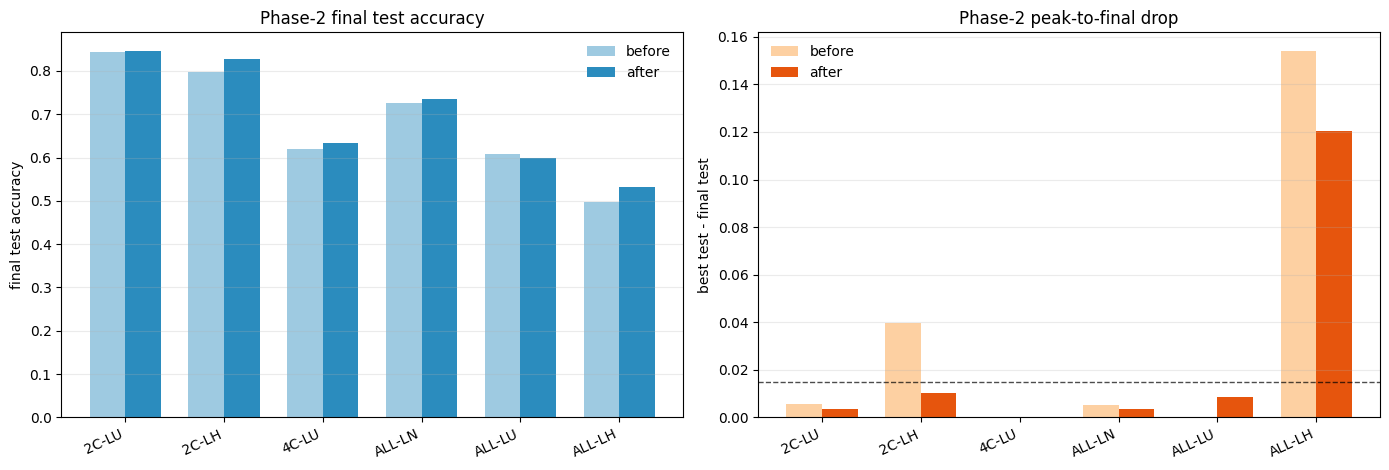

In [7]:
# Phase-2 recovery: continue from 5-epoch recovered checkpoints for networks that are still not converged
PHASE2_RUN = True
PHASE2_EXTRA_EPOCHS = 5
PHASE2_PATIENCE = 3
PHASE2_MIN_DELTA = 0.0015
PHASE2_BATCH_LIMIT = None
PHASE2_SAVE = True

# Status-aware LR scaling (smaller steps for unstable runs)
STATUS_LR_SCALE = {
    "peaked then regressed": 0.15,
    "mixed": 0.35,
    "near plateau": 0.45,
    "still improving": 0.60,
}
# Network-specific override for previously unstable all-class Local-Hom run
NETWORK_LR_SCALE = {
    "ALL-LH": 0.08,
}

print("Phase-2 recovery config")
print("-" * 80)
print(f"PHASE2_RUN={PHASE2_RUN}")
print(f"extra_epochs={PHASE2_EXTRA_EPOCHS} | patience={PHASE2_PATIENCE} | min_delta={PHASE2_MIN_DELTA}")
print(f"batch_limit={PHASE2_BATCH_LIMIT}")

if "recovery_df_5ep" not in globals() or recovery_df_5ep.empty:
    raise RuntimeError("recovery_df_5ep is missing. Run the 5-epoch recovery cell first.")

if "SHD_TRAIN_CACHE" not in globals() or "SHD_TEST_CACHE" not in globals():
    print("Loading SHD caches...")
    SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
    SHD_TEST_CACHE = SHDCache(SHD_TEST)

catalog_by_short = {entry["short"]: entry for entry in NETWORK_CATALOG}
phase2_targets = recovery_df_5ep[~recovery_df_5ep["after_converged"]].copy()
phase2_targets = phase2_targets.sort_values(["task", "delta_final_test"], ascending=[True, False]).reset_index(drop=True)

print("\nPhase-2 targets (still not converged after 5-epoch pass)")
print("-" * 100)
if phase2_targets.empty:
    print("No targets remain. All recovered networks are converged.")
else:
    print(phase2_targets[["short", "task", "after_status", "after_final_test", "after_best_minus_final"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

phase2_rows = []
for _, target in phase2_targets.iterrows():
    short = target["short"]
    task = target["task"]
    entry = catalog_by_short[short]

    start_ckpt = Path(target["saved_checkpoint"]) if isinstance(target["saved_checkpoint"], str) and target["saved_checkpoint"] else Path(entry["checkpoint"])
    if not start_ckpt.exists():
        start_ckpt = Path(entry["checkpoint"])

    checkpoint = torch.load(start_ckpt, map_location=DEVICE, weights_only=False)
    history_before = checkpoint.get("history", {})
    before_metrics = score_history(history_before.get("train_acc", []), history_before.get("test_acc", []))

    saved_prms = dict(checkpoint.get("prms", {}))
    prms = dict(saved_prms)
    prms.update(TASK_OVERRIDES[task])
    prms["device"] = DEVICE
    prms["dtype"] = torch.float
    prms["cuda"] = DEVICE.type == "cuda"
    prms["drop_last"] = bool(prms.get("drop_last", True))
    prms["batch_size"] = int(prms.get("batch_size", 256))
    prms["nb_steps"] = int(prms.get("nb_steps", 1000))
    prms["nb_inputs"] = int(prms.get("nb_inputs", 700))
    prms["time_step"] = float(prms.get("time_step", 1e-3))
    prms["weight_decay"] = float(prms.get("weight_decay", 0.0))
    prms["betas"] = tuple(prms.get("betas", (0.9, 0.999)))

    base_lr = float(prms.get("lr", 4e-3))
    base_lr_ab = float(prms.get("lr_ab", base_lr))
    status_key = str(target.get("after_status", "mixed"))
    lr_scale = NETWORK_LR_SCALE.get(short, STATUS_LR_SCALE.get(status_key, 0.40))
    prms["lr"] = max(base_lr * lr_scale, 5e-5)
    prms["lr_ab"] = max(base_lr_ab * lr_scale, 5e-5)

    if "seed" not in prms:
        prms["seed"] = 1000
    set_seed(int(prms["seed"]))

    model = RSNN(prms, rec=True).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    ext_history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    stop_reason = "not run"
    ran_epochs = 0

    print(f"\n[{short}] task={task} | status_before={before_metrics['status']} | start_ckpt={start_ckpt.name}")
    print(f"  LR adjusted: {base_lr:.6f} -> {prms['lr']:.6f} | lr_ab {base_lr_ab:.6f} -> {prms['lr_ab']:.6f}")

    if PHASE2_RUN:
        ext_history, stop_reason, ran_epochs = continue_training(
            model,
            prms,
            SHD_TRAIN_CACHE,
            SHD_TEST_CACHE,
            extra_epochs=PHASE2_EXTRA_EPOCHS,
            patience=PHASE2_PATIENCE,
            min_delta=PHASE2_MIN_DELTA,
            batch_limit=PHASE2_BATCH_LIMIT,
            use_amp=True,
        )

    history_after = merge_histories(history_before, ext_history)
    after_metrics = score_history(history_after.get("train_acc", []), history_after.get("test_acc", []))

    saved_path = ""
    if PHASE2_RUN and PHASE2_SAVE:
        RECOVERY_DIR.mkdir(parents=True, exist_ok=True)
        out_path = RECOVERY_DIR / f"{start_ckpt.stem}_recovery_more.pt"
        payload = {
            "model_state_dict": model.state_dict(),
            "history": history_after,
            "elapsed_s": float(checkpoint.get("elapsed_s", 0.0)),
            "prms": {k: v for k, v in prms.items() if not isinstance(v, (torch.device, torch.dtype))},
            "source_checkpoint": str(start_ckpt),
            "phase2_config": {
                "extra_epochs": int(PHASE2_EXTRA_EPOCHS),
                "patience": int(PHASE2_PATIENCE),
                "min_delta": float(PHASE2_MIN_DELTA),
                "batch_limit": None if PHASE2_BATCH_LIMIT is None else int(PHASE2_BATCH_LIMIT),
                "lr_scale": float(lr_scale),
                "ran_epochs": int(ran_epochs),
            },
            "stop_reason": stop_reason,
        }
        torch.save(payload, out_path)
        saved_path = str(out_path)

    print(f"  After: final_test={after_metrics['final_test_acc']:.4f}, status={after_metrics['status']} | converged={after_metrics['converged']}")

    phase2_rows.append(
        {
            "short": short,
            "task": task,
            "start_checkpoint": str(start_ckpt),
            "lr_scale": float(lr_scale),
            "before_status": before_metrics["status"],
            "after_status": after_metrics["status"],
            "before_converged": bool(before_metrics["converged"]),
            "after_converged": bool(after_metrics["converged"]),
            "before_final_test": before_metrics["final_test_acc"],
            "after_final_test": after_metrics["final_test_acc"],
            "delta_final_test": after_metrics["final_test_acc"] - before_metrics["final_test_acc"],
            "before_best_minus_final": before_metrics["best_minus_final"],
            "after_best_minus_final": after_metrics["best_minus_final"],
            "delta_best_minus_final": after_metrics["best_minus_final"] - before_metrics["best_minus_final"],
            "extra_epochs_ran": int(ran_epochs),
            "stop_reason": stop_reason,
            "saved_checkpoint": saved_path,
        }
    )

phase2_df = pd.DataFrame(phase2_rows)

print("\nPhase-2 recovery summary")
print("-" * 170)
if phase2_df.empty:
    print("No phase-2 recovery rows produced.")
else:
    print(phase2_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

if not phase2_df.empty:
    newly_converged_2 = int((~phase2_df["before_converged"] & phase2_df["after_converged"]).sum())
    still_not_converged_2 = int((~phase2_df["after_converged"]).sum())
    mean_delta_acc_2 = float(phase2_df["delta_final_test"].mean())

    print("\nPhase-2 aggregate stats")
    print("-" * 70)
    print(f"networks run: {len(phase2_df)}")
    print(f"newly converged in phase-2: {newly_converged_2}")
    print(f"still not converged after phase-2: {still_not_converged_2}")
    print(f"mean delta final test acc: {mean_delta_acc_2:.4f}")

    x = np.arange(len(phase2_df))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    axes[0].bar(x - 0.18, phase2_df["before_final_test"], width=0.36, label="before", color="#9ecae1")
    axes[0].bar(x + 0.18, phase2_df["after_final_test"], width=0.36, label="after", color="#2b8cbe")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(phase2_df["short"], rotation=25, ha="right")
    axes[0].set_title("Phase-2 final test accuracy")
    axes[0].set_ylabel("final test accuracy")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].bar(x - 0.18, phase2_df["before_best_minus_final"], width=0.36, label="before", color="#fdd0a2")
    axes[1].bar(x + 0.18, phase2_df["after_best_minus_final"], width=0.36, label="after", color="#e6550d")
    axes[1].axhline(0.015, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(phase2_df["short"], rotation=25, ha="right")
    axes[1].set_title("Phase-2 peak-to-final drop")
    axes[1].set_ylabel("best test - final test")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend(frameon=False)

    plt.tight_layout()
    plt.show()

In [8]:
if "phase2_df" not in globals() or phase2_df.empty:
    print("phase2_df is missing or empty. Re-run the Phase-2 cell first.")
else:
    view_cols = [
        "short",
        "task",
        "before_status",
        "after_status",
        "before_converged",
        "after_converged",
        "before_final_test",
        "after_final_test",
        "delta_final_test",
        "before_best_minus_final",
        "after_best_minus_final",
        "delta_best_minus_final",
        "extra_epochs_ran",
        "lr_scale",
    ]
    print("Phase-2 key table")
    print("-" * 170)
    print(phase2_df[view_cols].to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    newly_converged = int((~phase2_df["before_converged"] & phase2_df["after_converged"]).sum())
    still_not_converged = int((~phase2_df["after_converged"]).sum())
    improved_acc = int((phase2_df["delta_final_test"] > 0).sum())
    worsened_acc = int((phase2_df["delta_final_test"] < 0).sum())

    print("\nPhase-2 aggregate")
    print("-" * 70)
    print(f"networks run: {len(phase2_df)}")
    print(f"newly converged: {newly_converged}")
    print(f"still not converged: {still_not_converged}")
    print(f"improved final test acc: {improved_acc}")
    print(f"worsened final test acc: {worsened_acc}")
    print(f"mean delta final test acc: {phase2_df['delta_final_test'].mean():.4f}")
    print(f"mean delta (best-final drop): {phase2_df['delta_best_minus_final'].mean():.4f}")

    if "saved_checkpoint" in phase2_df.columns:
        print("\nSaved phase-2 checkpoints")
        print("-" * 70)
        for p in phase2_df["saved_checkpoint"].tolist():
            if isinstance(p, str) and p:
                print(p)

Phase-2 key table
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 short      task         before_status          after_status  before_converged  after_converged  before_final_test  after_final_test  delta_final_test  before_best_minus_final  after_best_minus_final  delta_best_minus_final  extra_epochs_ran  lr_scale
 2C-LU   2-class                 mixed plateaued / converged             False             True             0.8445            0.8467            0.0022                   0.0057                  0.0035                 -0.0022                 5    0.3500
 2C-LH   2-class                 mixed                 mixed             False            False             0.7986            0.8282            0.0296                   0.0398                  0.0102                 -0.0296                 4    0.3500
 4C-LU   4-class       still improving       still impr